**1. Project Overview**

This project develops a binary classification system for predicting
Autism Spectrum Disorder (ASD) from screening, demographic and
questionnaire-related features.

The workflow includes exploratory data analysis, categorical and numerical
feature preprocessing, class-imbalance handling using SMOTENC, comparison
of multiple machine-learning algorithms, and hyperparameter optimization
using RandomizedSearchCV.

F1-score is used as the primary model-selection metric because the target
classes are imbalanced.

**2. IMPORTING THE BASIC LIBRARIES**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder , OrdinalEncoder , StandardScaler
from sklearn.model_selection import train_test_split,cross_val_score,RandomizedSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report,f1_score,recall_score,roc_auc_score,precision_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier,HistGradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import SMOTENC
from imblearn.pipeline import Pipeline

from xgboost import XGBClassifier
#pip install catboost
# from catboost import CatBoostClassifier
import warnings
warnings.filterwarnings('ignore')

import pickle

**3. DATA LOADING AND PRELIMINARY ANALYSIS**

In [4]:
df = pd.read_csv("/content/train.csv")
df_test = pd.read_csv("/content/test.csv")

df.head()

,ID,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,...,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,0,1,0,1,0,1,0,1,...,f,?,no,no,Austria,no,6.351166,18 and more,Self,0
1,2,0,0,0,0,0,0,0,0,0,...,m,?,no,no,India,no,2.255185,18 and more,Self,0
2,3,1,1,1,1,1,1,1,1,1,...,m,White-European,no,yes,United States,no,14.851484,18 and more,Self,1
3,4,0,0,0,0,0,0,0,0,0,...,f,?,no,no,United States,no,2.276617,18 and more,Self,0
4,5,0,0,0,0,0,0,0,0,0,...,m,?,no,no,South Africa,no,-4.777286,18 and more,Self,0


In [5]:
print(df.shape)
print(df_test.shape)

(800, 22)
(200, 21)


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               800 non-null    int64  
 1   A1_Score         800 non-null    int64  
 2   A2_Score         800 non-null    int64  
 3   A3_Score         800 non-null    int64  
 4   A4_Score         800 non-null    int64  
 5   A5_Score         800 non-null    int64  
 6   A6_Score         800 non-null    int64  
 7   A7_Score         800 non-null    int64  
 8   A8_Score         800 non-null    int64  
 9   A9_Score         800 non-null    int64  
 10  A10_Score        800 non-null    int64  
 11  age              800 non-null    float64
 12  gender           800 non-null    object 
 13  ethnicity        800 non-null    object 
 14  jaundice         800 non-null    object 
 15  austim           800 non-null    object 
 16  contry_of_res    800 non-null    object 
 17  used_app_before 

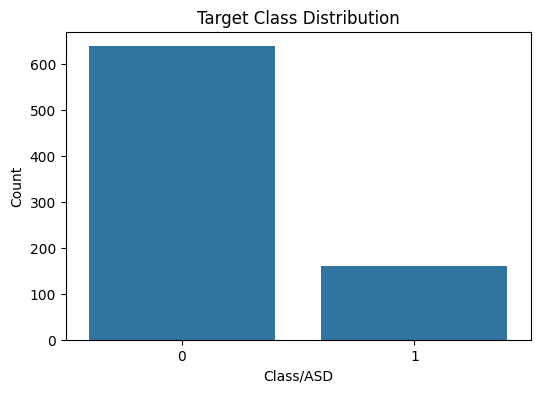

In [7]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Class/ASD")
plt.title("Target Class Distribution")
plt.xlabel("Class/ASD")
plt.ylabel("Count")
plt.show()

**4.DATA CLEANING**

In [8]:
df = df.drop(['ID','used_app_before','age_desc'],axis=1)
df.head()

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jaundice,austim,contry_of_res,result,relation,Class/ASD
0,1,0,1,0,1,0,1,0,1,1,38.172746,f,?,no,no,Austria,6.351166,Self,0
1,0,0,0,0,0,0,0,0,0,0,47.750517,m,?,no,no,India,2.255185,Self,0
2,1,1,1,1,1,1,1,1,1,1,7.380373,m,White-European,no,yes,United States,14.851484,Self,1
3,0,0,0,0,0,0,0,0,0,0,23.561927,f,?,no,no,United States,2.276617,Self,0
4,0,0,0,0,0,0,0,0,0,0,43.205790,m,?,no,no,South Africa,-4.777286,Self,0


In [9]:
df['age'] = df['age'].astype(int)

In [10]:
df.head()

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jaundice,austim,contry_of_res,result,relation,Class/ASD
0,1,0,1,0,1,0,1,0,1,1,38,f,?,no,no,Austria,6.351166,Self,0
1,0,0,0,0,0,0,0,0,0,0,47,m,?,no,no,India,2.255185,Self,0
2,1,1,1,1,1,1,1,1,1,1,7,m,White-European,no,yes,United States,14.851484,Self,1
3,0,0,0,0,0,0,0,0,0,0,23,f,?,no,no,United States,2.276617,Self,0
4,0,0,0,0,0,0,0,0,0,0,43,m,?,no,no,South Africa,-4.777286,Self,0


In [11]:
df.shape

(800, 19)

In [12]:
for col in df.columns:
  numerical_features = ['age','result']
  if col not in numerical_features:
    print(col ,df[col].unique())
    print("--"*50)

A1_Score [1 0]
----------------------------------------------------------------------------------------------------
A2_Score [0 1]
----------------------------------------------------------------------------------------------------
A3_Score [1 0]
----------------------------------------------------------------------------------------------------
A4_Score [0 1]
----------------------------------------------------------------------------------------------------
A5_Score [1 0]
----------------------------------------------------------------------------------------------------
A6_Score [0 1]
----------------------------------------------------------------------------------------------------
A7_Score [1 0]
----------------------------------------------------------------------------------------------------
A8_Score [0 1]
----------------------------------------------------------------------------------------------------
A9_Score [1 0]
---------------------------------------------------------

In [13]:
df.columns

Index(['A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score',
       'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age', 'gender',
       'ethnicity', 'jaundice', 'austim', 'contry_of_res', 'result',
       'relation', 'Class/ASD'],
      dtype='object')

In [14]:
mapping = {
    'Viet Nam':'Vietnam',
    'AmericanSamoa':'Samoa'
           }
df['contry_of_res'] = df['contry_of_res'].replace(mapping)

In [15]:
df['contry_of_res'].unique()

array(['Austria', 'India', 'United States', 'South Africa', 'Jordan',
       'United Kingdom', 'Brazil', 'New Zealand', 'Canada', 'Kazakhstan',
       'United Arab Emirates', 'Australia', 'Ukraine', 'Iraq', 'France',
       'Malaysia', 'Vietnam', 'Egypt', 'Netherlands', 'Afghanistan',
       'Oman', 'Italy', 'Samoa', 'Bahamas', 'Saudi Arabia', 'Ireland',
       'Aruba', 'Sri Lanka', 'Russia', 'Bolivia', 'Azerbaijan', 'Armenia',
       'Serbia', 'Ethiopia', 'Sweden', 'Iceland', 'Hong Kong', 'Angola',
       'China', 'Germany', 'Spain', 'Tonga', 'Pakistan', 'Iran',
       'Argentina', 'Japan', 'Mexico', 'Nicaragua', 'Sierra Leone',
       'Czech Republic', 'Niger', 'Romania', 'Cyprus', 'Belgium',
       'Burundi', 'Bangladesh'], dtype=object)

In [16]:
#target class distribution
df['Class/ASD'].value_counts()

,count
Class/ASD,
0,639
1,161


**5. EDA**

In [17]:
df.shape

(800, 19)

In [18]:
df.describe()

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,result,Class/ASD
count,800.000000,800.000000,800.000000,800.00000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000
mean,0.560000,0.530000,0.450000,0.41500,0.395000,0.303750,0.397500,0.508750,0.495000,0.617500,27.963750,8.537303,0.201250
std,0.496697,0.499411,0.497805,0.49303,0.489157,0.460164,0.489687,0.500236,0.500288,0.486302,16.329827,4.807676,0.401185
min,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,-6.137748,0.000000
25%,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,17.000000,5.306575,0.000000
50%,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,24.000000,9.605299,0.000000
75%,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,35.250000,12.514484,0.000000
max,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,89.000000,15.853126,1.000000


Univariate Analysis

Numerical Columns:
- Age
- Result

Distribution Plot

Mean: 27.96375
Median: 24.0


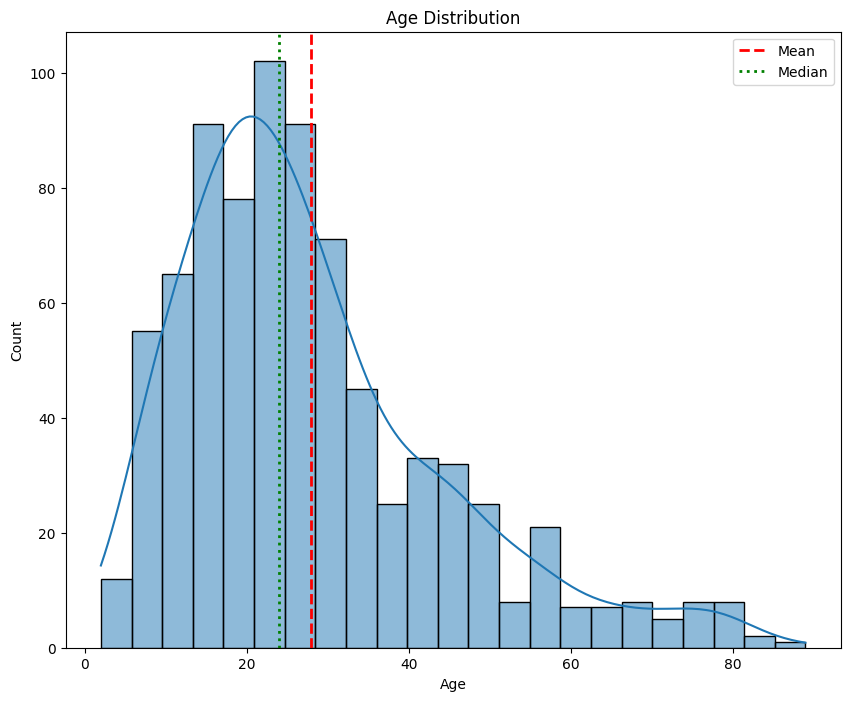

In [19]:
#Histogram for age column
plt.figure(figsize=(10,8))
sns.histplot(df['age'],kde=True)
plt.title('Age Distribution')
age_mean = df['age'].mean()
age_median = df['age'].median()
plt.axvline(age_mean,color='red',linestyle='dashed',linewidth=2,label='Mean')
plt.axvline(age_median,color='green',linestyle='dotted',linewidth=2,label='Median')
plt.legend()
print('Mean:',age_mean)
print('Median:',age_median)
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

Mean: 8.537303106501248
Median: 9.605299308


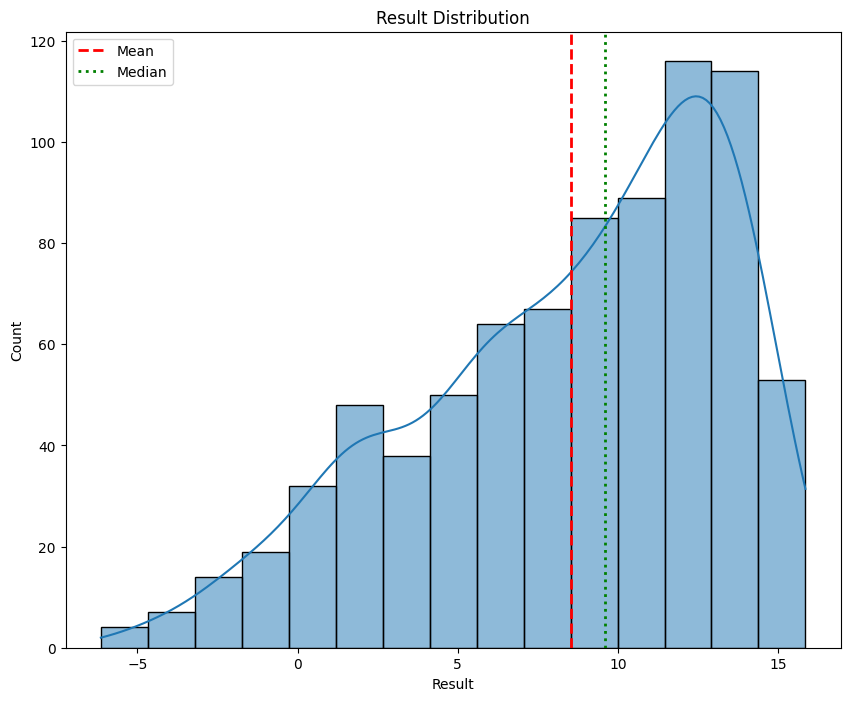

In [20]:
#Histogram for result column
plt.figure(figsize=(10,8))
sns.histplot(df['result'],kde=True)
plt.title('Result Distribution')
result_mean = df['result'].mean()
result_median = df['result'].median()
plt.axvline(result_mean,color='red',linestyle='dashed',linewidth=2,label='Mean')
plt.axvline(result_median,color='green',linestyle='dotted',linewidth=2,label='Median')
plt.legend()
print("Mean:",result_mean)
print("Median:",result_median)
plt.xlabel('Result')
plt.ylabel('Count')
plt.show()

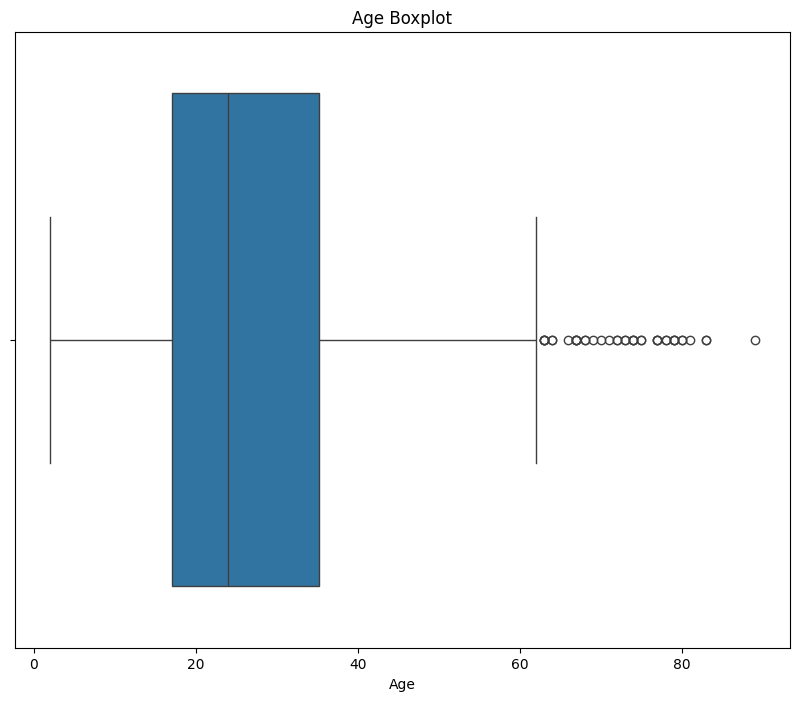

In [21]:
#BOXPLOT for age
plt.figure(figsize=(10,8))
sns.boxplot(x=df['age'])
plt.title('Age Boxplot')
plt.xlabel('Age')
plt.show()

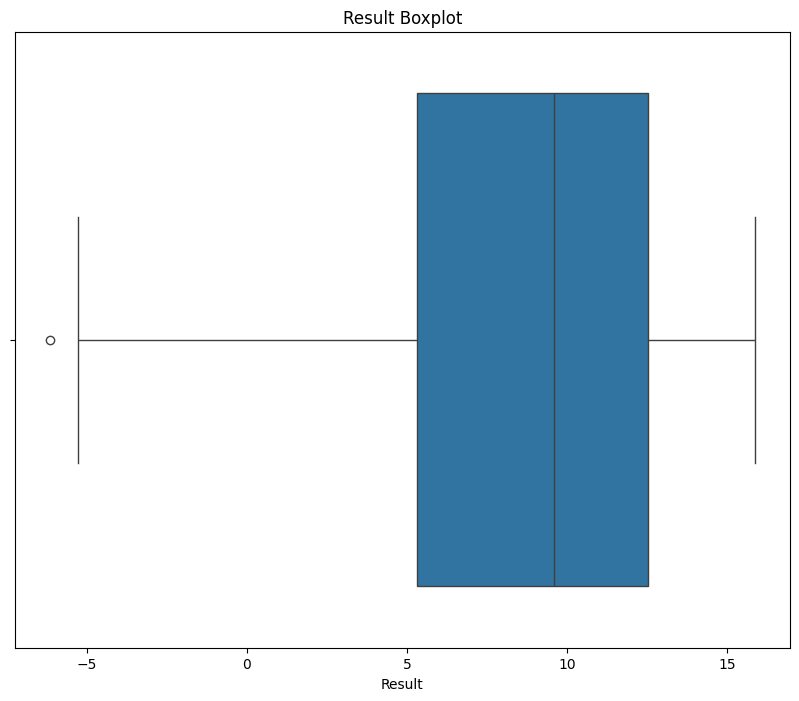

In [22]:
#BOXPLOT for result
plt.figure(figsize=(10,8))
sns.boxplot(x=df['result'])
plt.title('Result Boxplot')
plt.xlabel('Result')
plt.show()

In [23]:
#COUNTING NO. of OUTLIERS FOR age
Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)
IQR = Q3-Q1
lower_limit = Q1-1.5*IQR
upper_limit = Q3+1.5*IQR
out_age=0
for umar in df['age']:
  if(umar>upper_limit or umar<lower_limit):
    out_age+=1
    out_age_df = df[(df['age']>upper_limit) | (df['age']<lower_limit)]
print("Outliers for Age:",out_age)
print(out_age_df)

Outliers for Age: 39
     A1_Score  A2_Score  A3_Score  A4_Score  A5_Score  A6_Score  A7_Score  \
19          1         1         1         1         1         1         1   
31          0         1         0         0         0         0         0   
33          1         1         1         1         1         1         1   
41          1         1         1         1         1         0         1   
92          0         1         1         1         1         1         0   
93          0         0         0         0         0         0         0   
161         1         1         1         1         1         1         1   
231         1         1         1         1         1         1         1   
238         1         1         1         1         1         0         1   
241         0         0         0         0         0         0         0   
262         1         1         1         1         1         1         1   
264         1         1         1         1         1  

In [24]:
#COUNTING NO. of OUTLIERS FOR result
Q1 = df['result'].quantile(0.25)
Q3 = df['result'].quantile(0.75)
IQR = Q3-Q1
lower_limit = Q1-1.5*IQR
upper_limit = Q3+1.5*IQR
out_result=0
for uresult in df['result']:
  if(uresult>upper_limit or uresult<lower_limit):
    out_result+=1
    out_result_df = df[(df['result']>upper_limit) | (df['result']<lower_limit)]
print("Outliers for result:",out_result)
print(out_result_df)

Outliers for result: 1
     A1_Score  A2_Score  A3_Score  A4_Score  A5_Score  A6_Score  A7_Score  \
698         0         0         0         0         0         0         0   

     A8_Score  A9_Score  A10_Score  age gender ethnicity jaundice austim  \
698         0         0          0   62      f     Asian       no     no   

    contry_of_res    result relation  Class/ASD  
698        Jordan -6.137748     Self          0  


Univariate Analysis Of Categorical Column

In [25]:
df.columns

Index(['A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score',
       'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age', 'gender',
       'ethnicity', 'jaundice', 'austim', 'contry_of_res', 'result',
       'relation', 'Class/ASD'],
      dtype='object')

In [26]:
categorical_feat = ['A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score',
       'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score','gender',
       'ethnicity', 'jaundice', 'austim', 'contry_of_res',
       'relation']

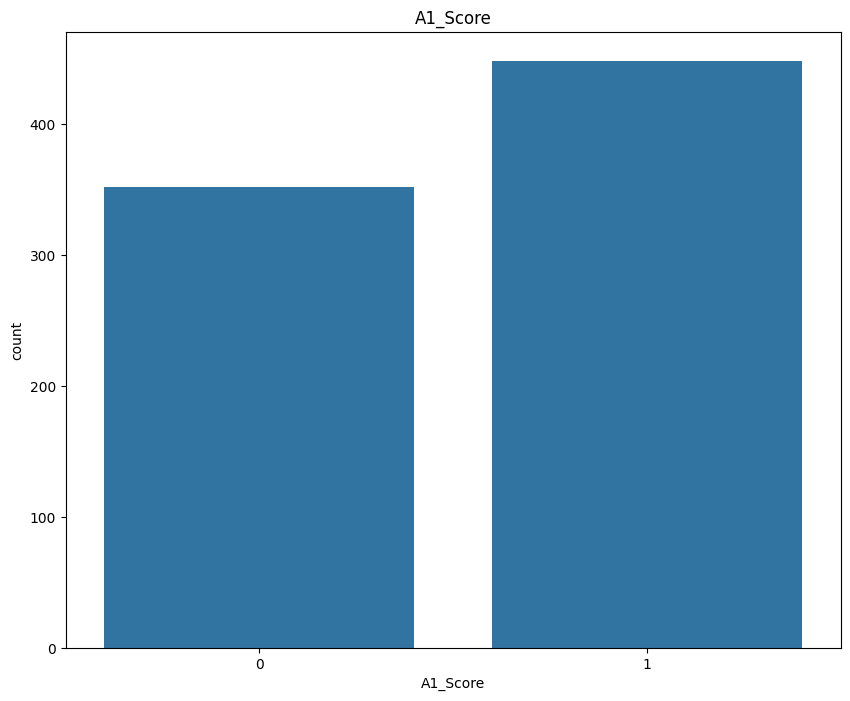

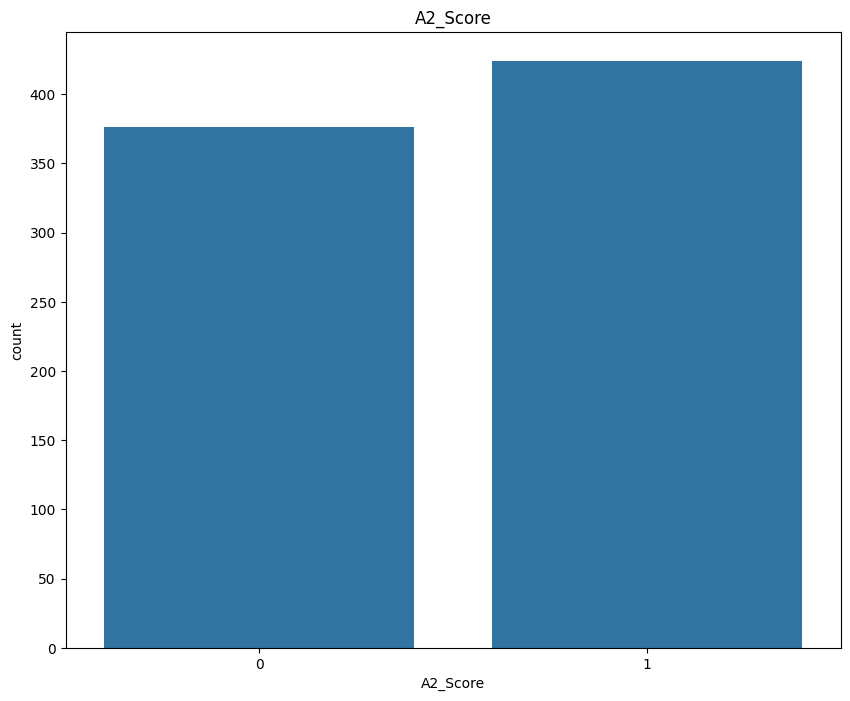

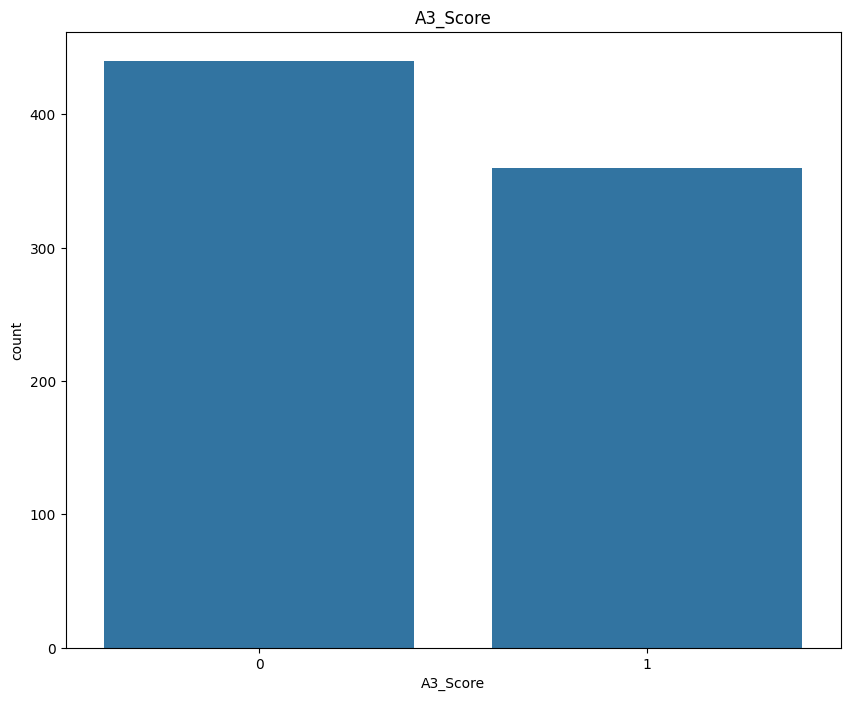

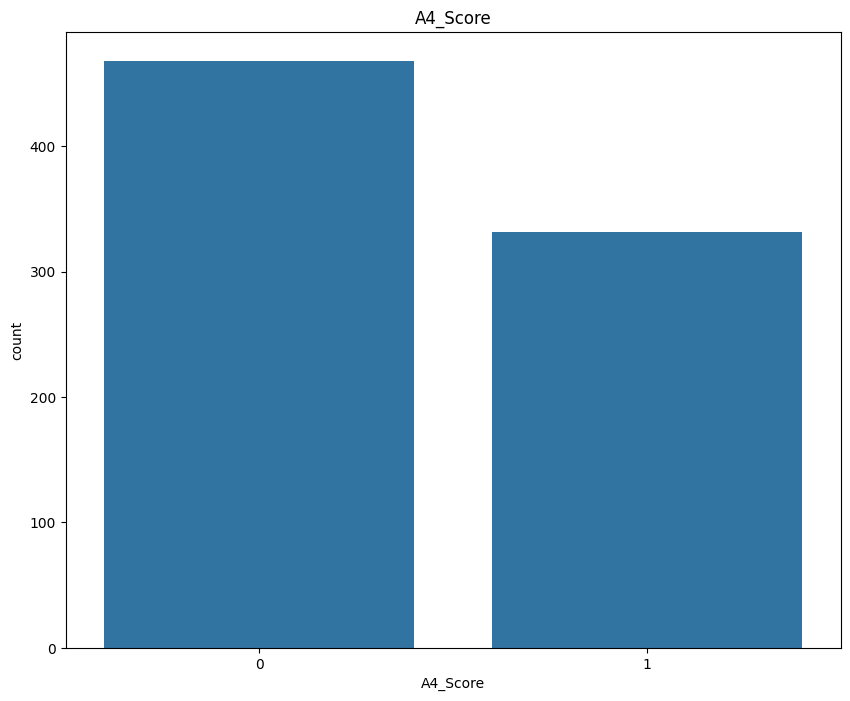

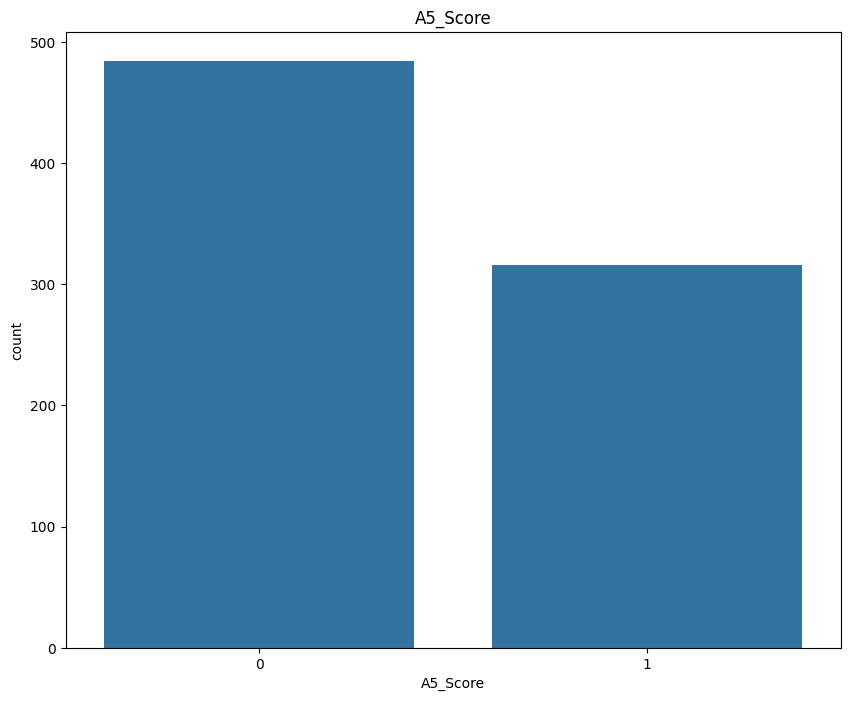

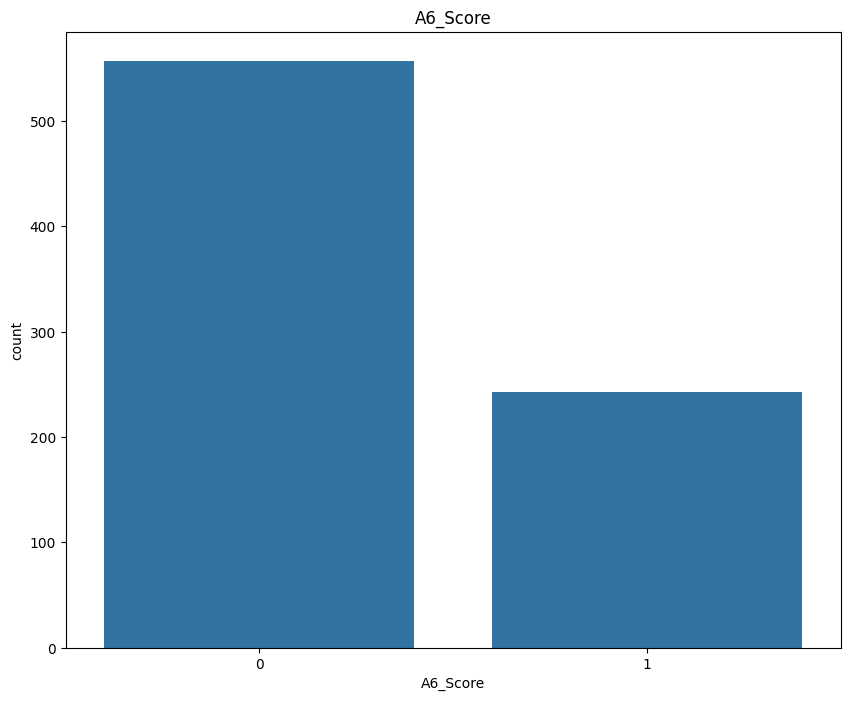

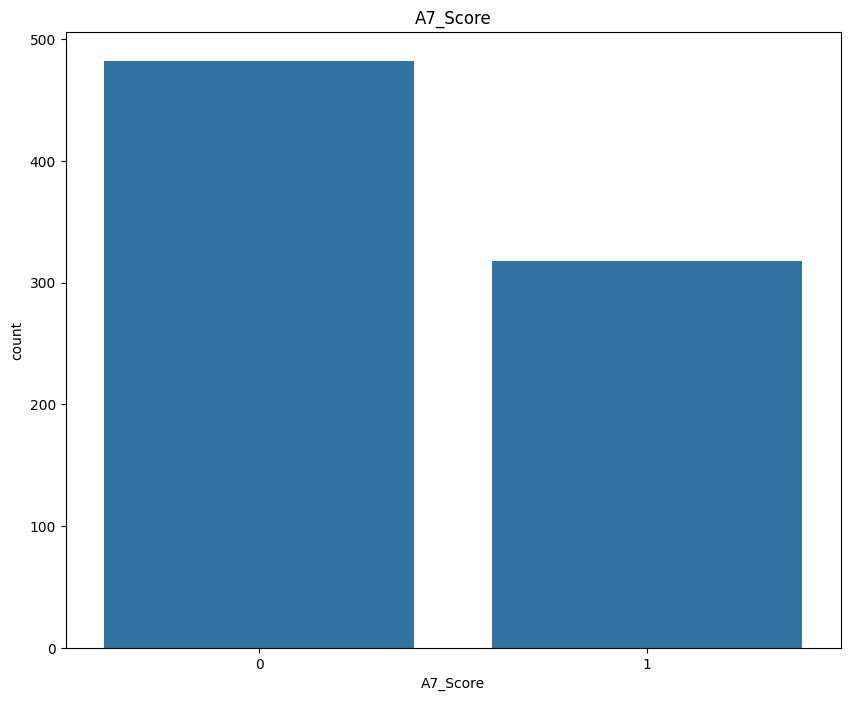

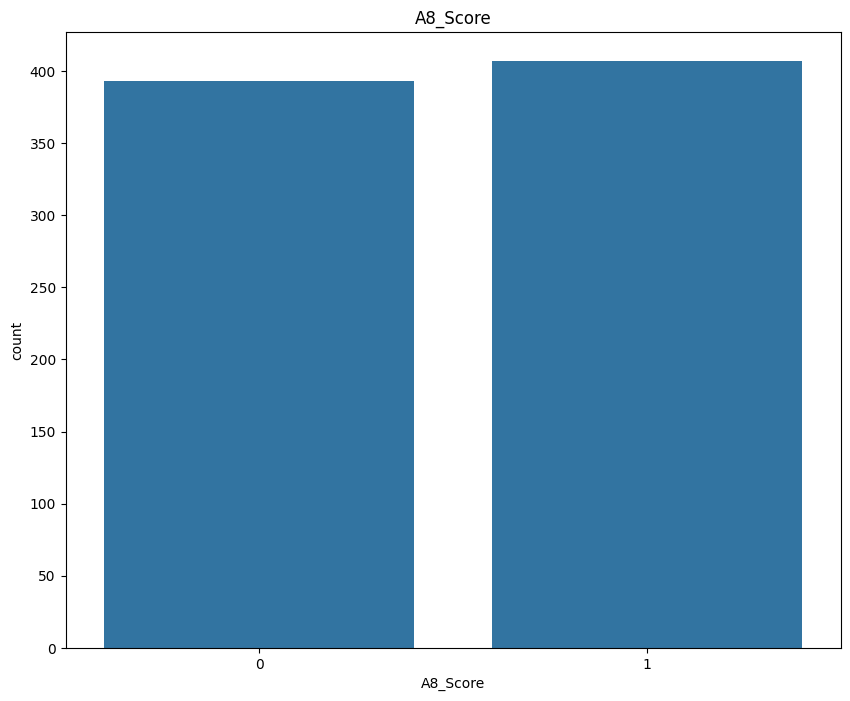

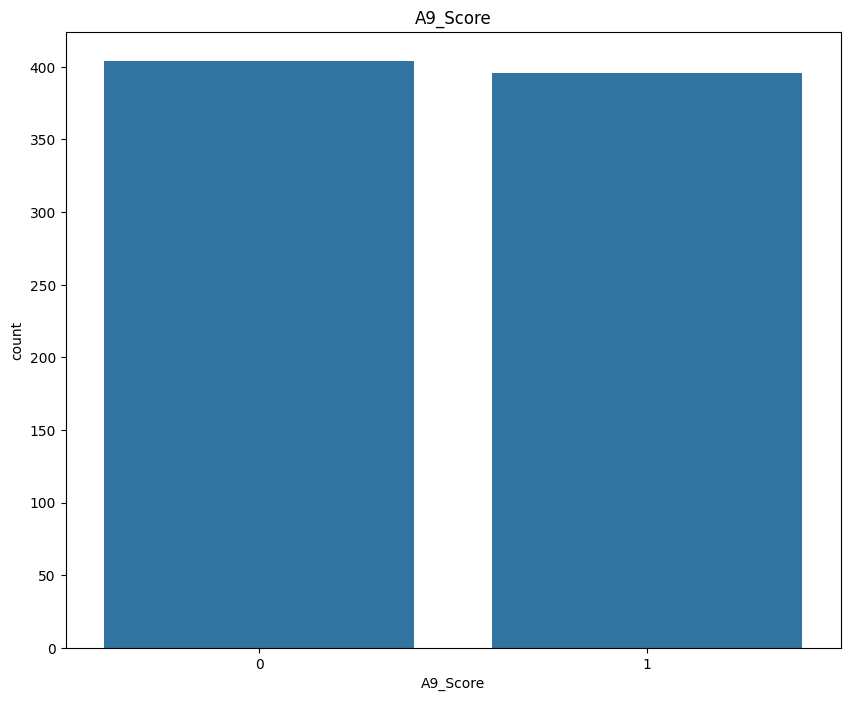

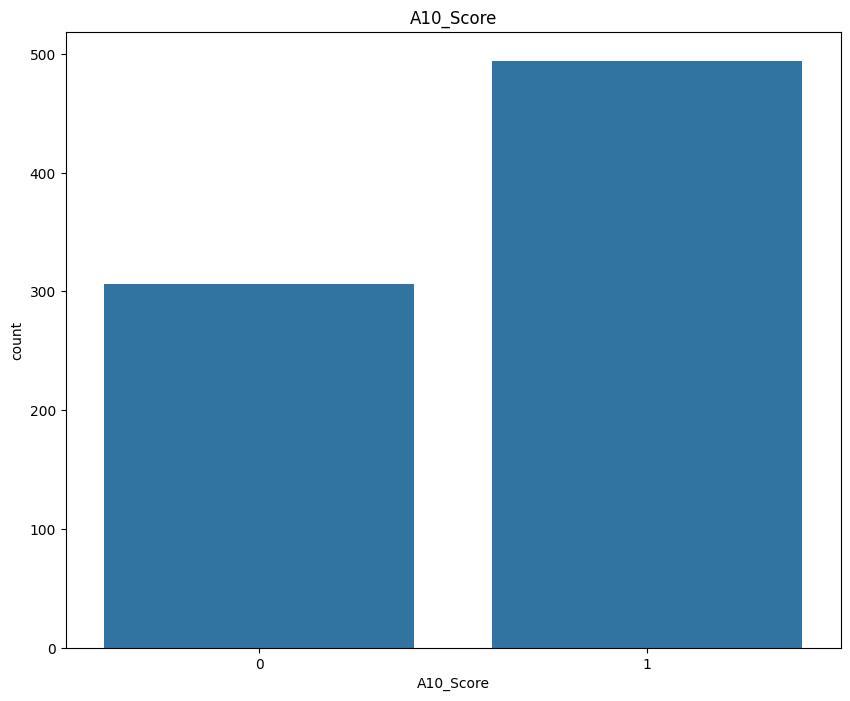

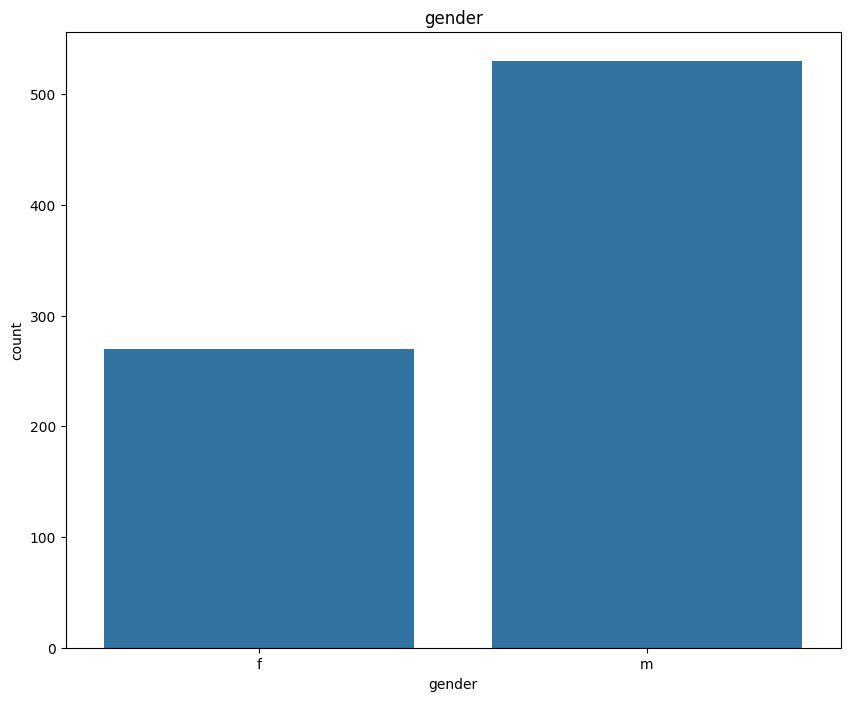

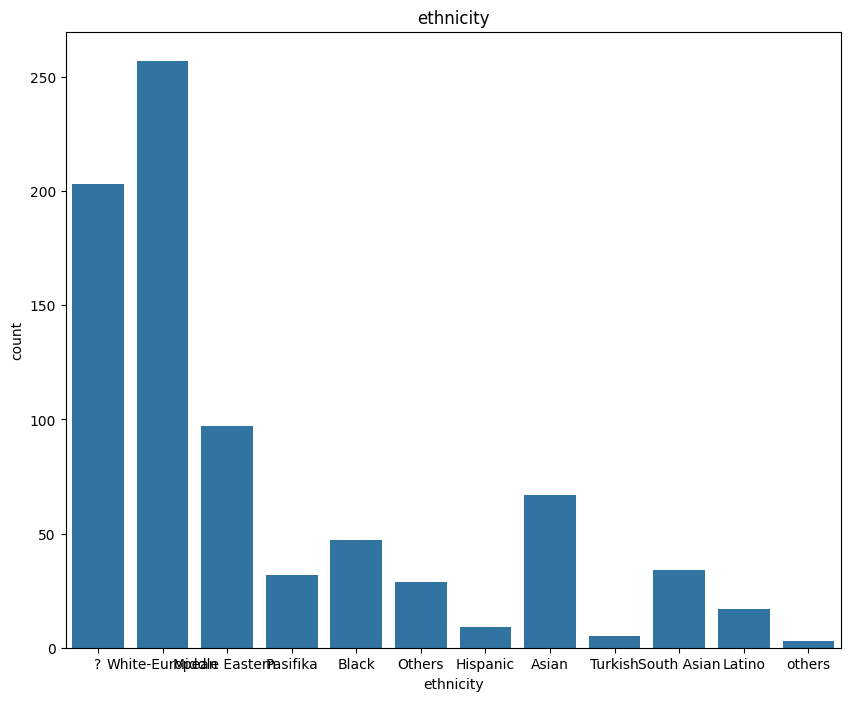

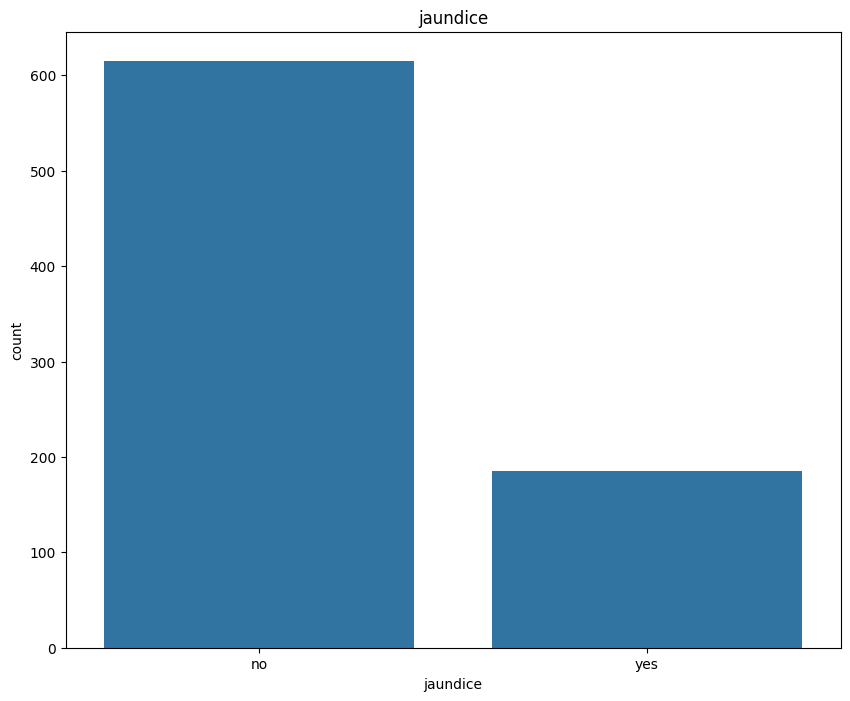

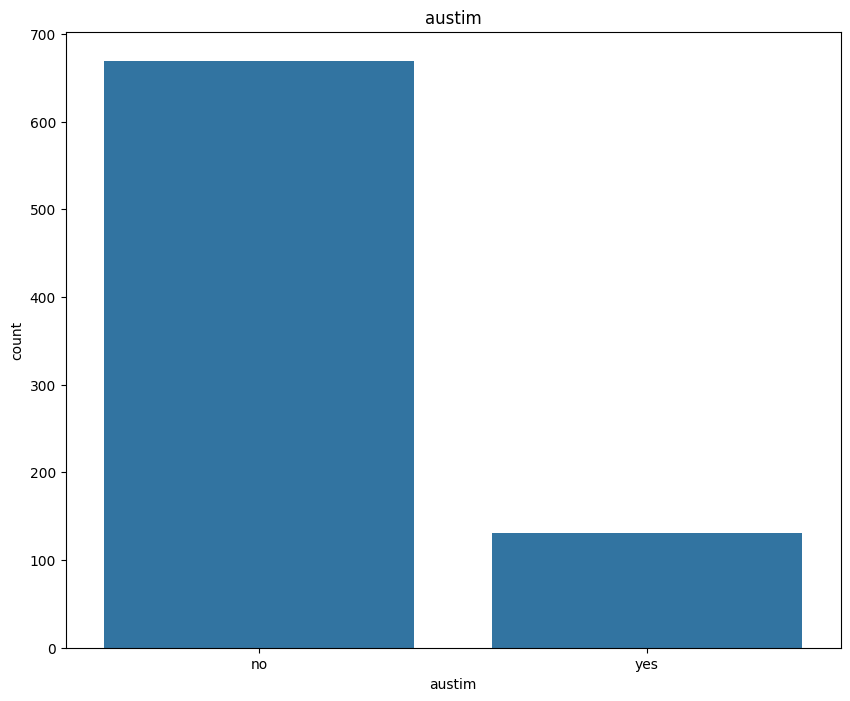

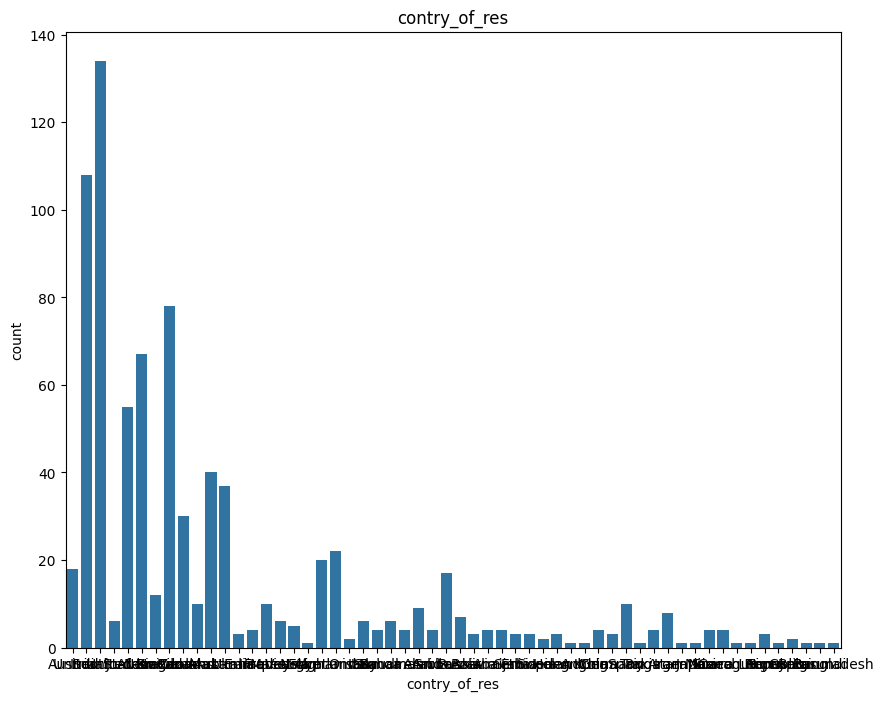

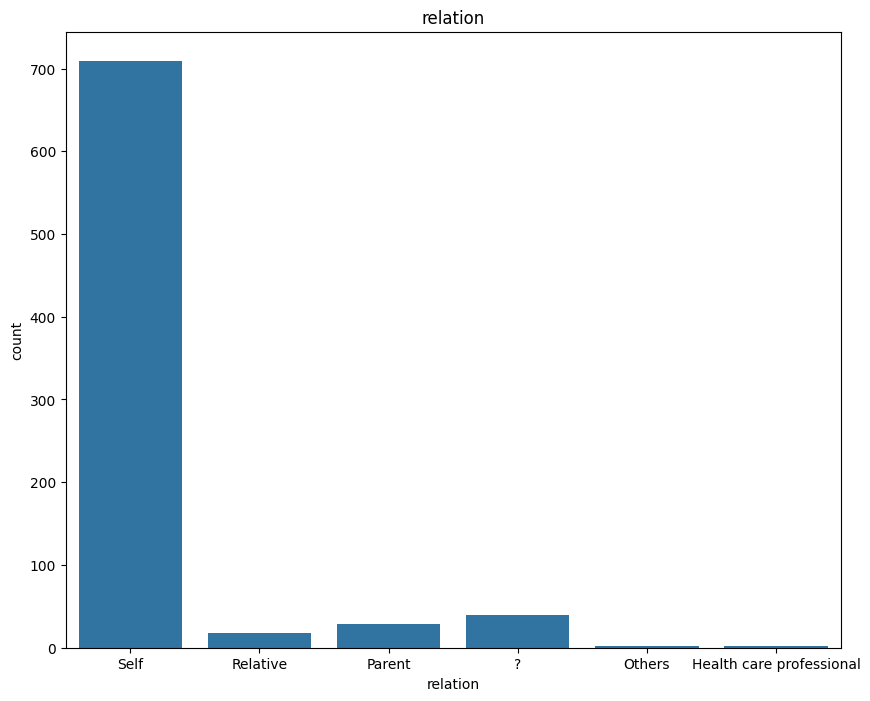

In [27]:
for col in categorical_feat:
  plt.figure(figsize=(10,8))
  sns.countplot(x=df[col])
  plt.title(col)
  plt.show()

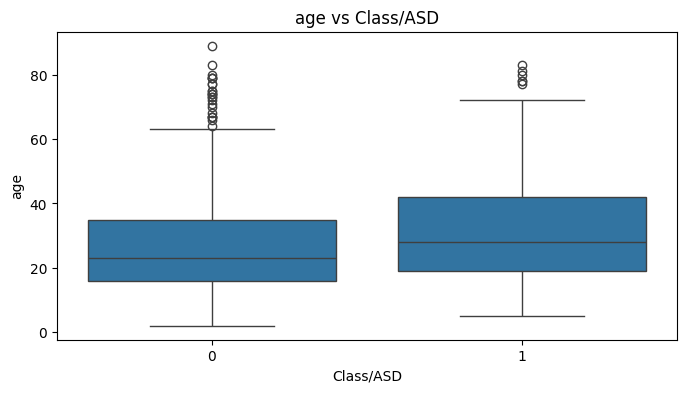

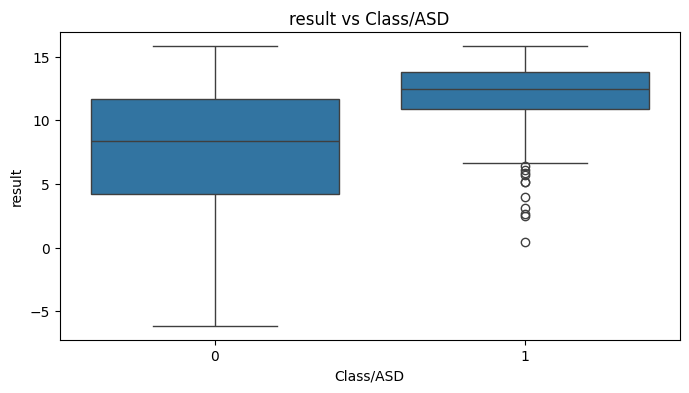

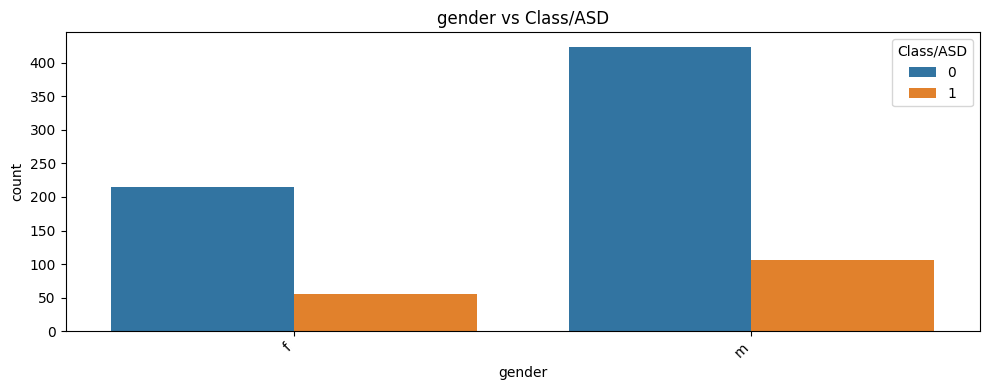

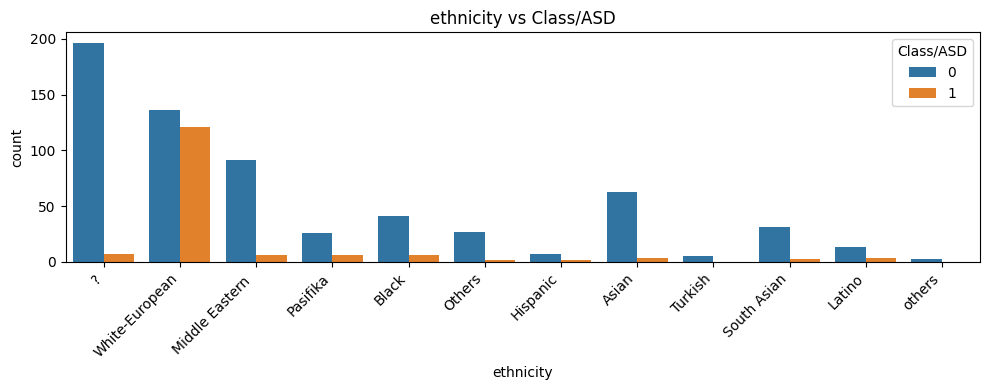

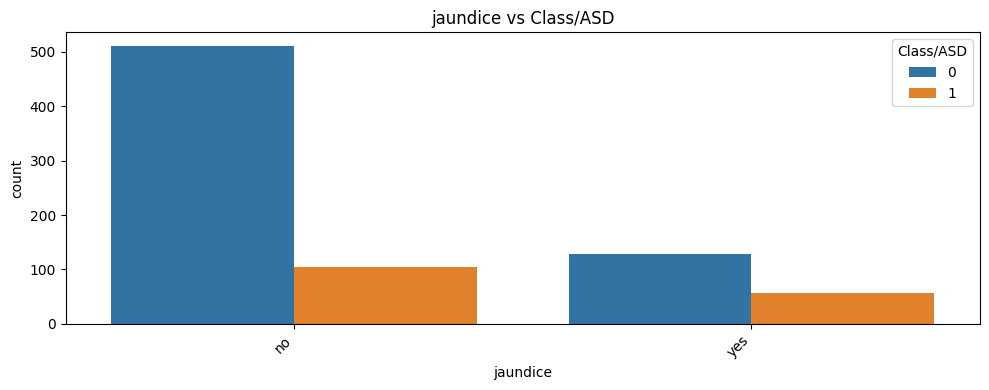

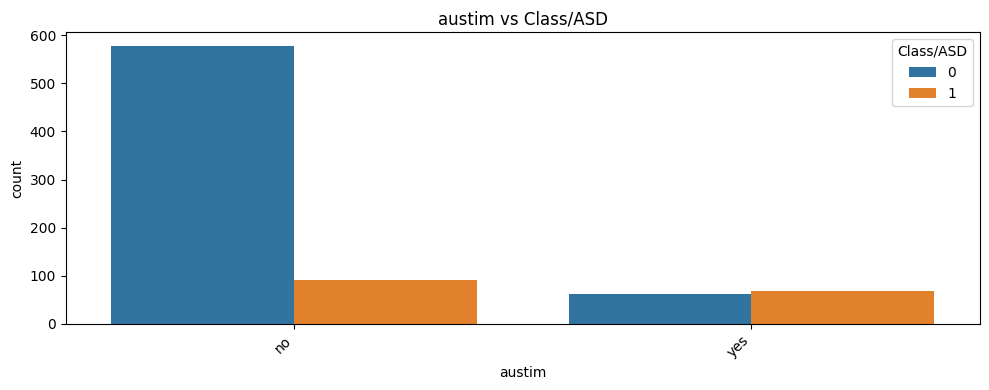

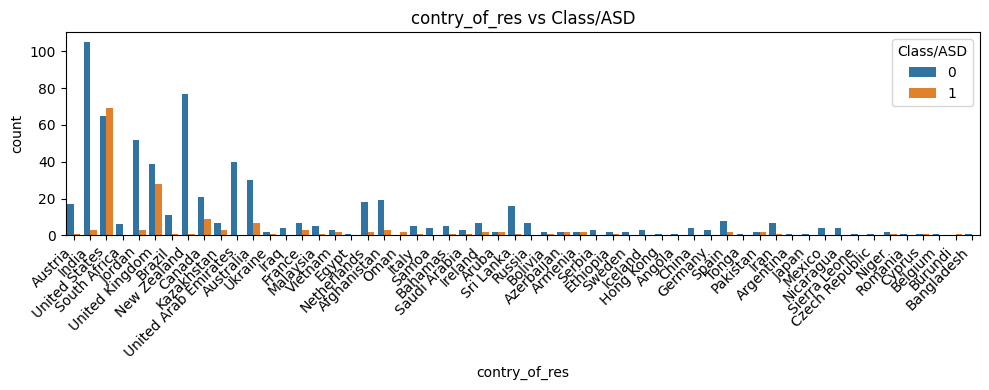

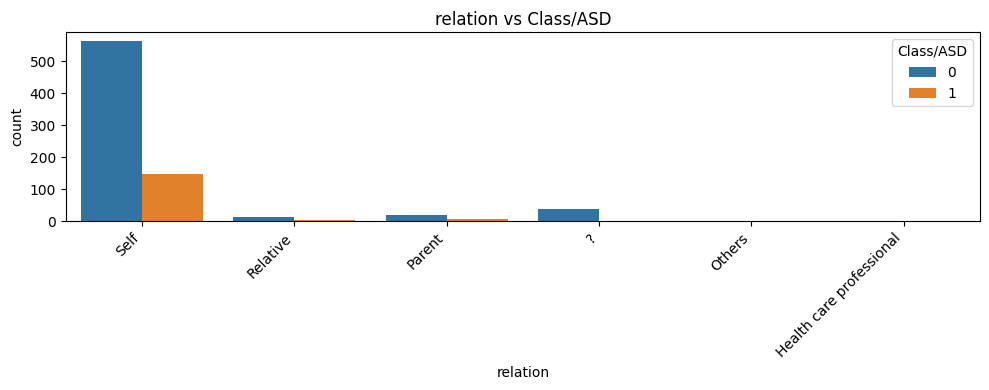

In [28]:
categorical_eda = [
    "gender",
    "ethnicity",
    "jaundice",
    "austim",
    "contry_of_res",
    "relation"
]

for col in ["age", "result"]:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df, x="Class/ASD", y=col)
    plt.title(f"{col} vs Class/ASD")
    plt.show()

for col in categorical_eda:
    plt.figure(figsize=(10, 4))
    sns.countplot(data=df, x=col, hue="Class/ASD")
    plt.title(f"{col} vs Class/ASD")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

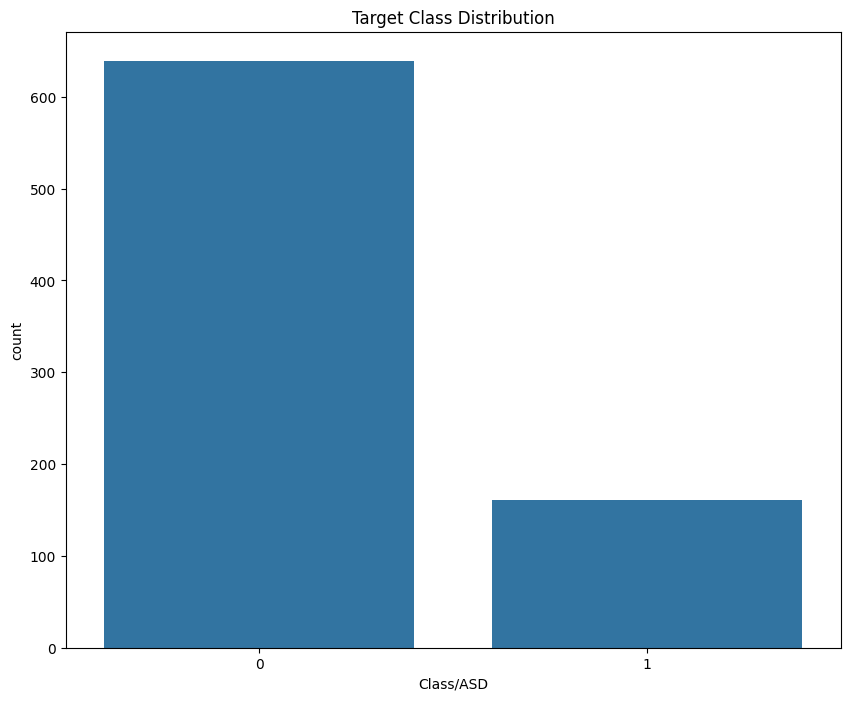

In [29]:
#count plot for Target
plt.figure(figsize=(10,8))
sns.countplot(x=df['Class/ASD'])
plt.title('Target Class Distribution')
plt.show()

In [30]:
#Value count for Target
df['Class/ASD'].value_counts()

,count
Class/ASD,
0,639
1,161


In [31]:
mapping_ethnicity = {
    '?':'Others',
    'others':'Others'
}
df.ethnicity = df.ethnicity.replace(mapping_ethnicity)

**6. Train Test Split**

In [32]:
X = df.drop('Class/ASD',axis=1)
y = df['Class/ASD']

In [33]:
X_train , X_val, y_train, y_val = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [34]:
X_train.shape

(640, 18)

In [35]:
X_val.shape

(160, 18)

In [36]:
y_train.value_counts()

,count
Class/ASD,
0,511
1,129


In [37]:
y_val.value_counts()

,count
Class/ASD,
0,128
1,32


**7.Feature Preprocessing**

In [38]:
from sklearn.compose import ColumnTransformer

categorical_cols = [
    'gender',
    'ethnicity',
    'jaundice',
    'austim',
    'contry_of_res',
    'relation'
]

numeric_cols = [
    'age',
    'result',
    'A1_Score',
    'A2_Score',
    'A3_Score',
    'A4_Score',
    'A5_Score',
    'A6_Score',
    'A7_Score',
    'A8_Score',
    'A9_Score',
    'A10_Score'
]

categorical_indices = list(
    range(len(numeric_cols), len(numeric_cols) + len(categorical_cols))
)

pre_smote = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_cols),
        (
            "cat",
            OrdinalEncoder(
                handle_unknown="use_encoded_value",
                unknown_value=-1
            ),
            categorical_cols
        )
    ],
    remainder="drop"
)

post_smote = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), list(range(len(numeric_cols)))),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_indices
        )
    ],
    remainder="drop"
)

print("Categorical indices for SMOTENC:", categorical_indices)

Categorical indices for SMOTENC: [12, 13, 14, 15, 16, 17]


<!-- Bivariate Analysis -->

Handling the Outliers


In [39]:
#handling outlier for age with median
Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)
IQR = Q3-Q1
lower_limit = Q1-1.5*IQR
upper_limit = Q3+1.5*IQR
for umar in df['age']:
  if(umar>upper_limit or umar<lower_limit):
    df['age'] = df['age'].replace(umar,age_median)

In [40]:
#handling outlier for result with median
Q1 = df['result'].quantile(0.25)
Q3 = df['result'].quantile(0.75)
IQR = Q3-Q1
lower_limit = Q1-1.5*IQR
upper_limit = Q3+1.5*IQR
for uresult in df['result']:
  if(uresult>upper_limit or uresult<lower_limit):
    df['result'] = df['result'].replace(uresult,result_median)

In [41]:
df.shape

(800, 19)

**8. Model Training**

In [42]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.7 MB/s eta 0:00:00


In [44]:
from imblearn.pipeline import Pipeline
from catboost import CatBoostClassifier

def make_pipeline(model):
    return Pipeline([
        ("pre_smote", pre_smote),
        (
            "smote",
            SMOTENC(
                categorical_features=categorical_indices,
                random_state=42
            )
        ),
        ("post_smote", post_smote),
        ("model", model)
    ])


models = {
    "lr": make_pipeline(
        LogisticRegression(
            solver="lbfgs",
            random_state=42
        )
    ),

    "dt": make_pipeline(
        DecisionTreeClassifier(
            random_state=42
        )
    ),

    "rf": make_pipeline(
        RandomForestClassifier(
            random_state=42,
            n_jobs=-1
        )
    ),

    "xgb": make_pipeline(
        XGBClassifier(
            random_state=42,
            eval_metric="logloss",
            n_jobs=-1
        )
    ),

    "gb": make_pipeline(
        GradientBoostingClassifier(
            random_state=42
        )
    ),

    "svc": make_pipeline(
        SVC(
            random_state=42,
            probability=True
        )
    ),

    "knn": make_pipeline(
        KNeighborsClassifier()
    ),

    "cat": make_pipeline(
        CatBoostClassifier(
            random_state=42,
            verbose=False,
            loss_function="Logloss"
        )
    )
}

print("Models:", list(models.keys()))

Models: ['lr', 'dt', 'rf', 'xgb', 'gb', 'svc', 'knn', 'cat']


**9.Model Selection And Hyperparameter Tuning**

In [45]:
param_grids = {

#hyperparameter tuning for logistic_regression
'lr' : [{ 'model__max_iter' : [500,1000,1500,2000],
                 'model__penalty' : ['l2'],
                  'model__C' :  [0.01, 0.1, 1, 10, 20]

}] ,

#hyperparameter tuning for svm
'svc' : [{
        'model__kernel': ['rbf'],
        'model__C': [0.1, 1, 10, 100],
        'model__gamma': ['scale', 'auto', 0.01, 0.1, 1]
    },
    {
        'model__kernel': ['poly'],
        'model__C': [0.1, 1, 10, 100],
        'model__gamma': ['scale', 'auto'],
        'model__degree': [2, 3, 4, 5]
    },
    {
        'model__kernel': ['linear'],
        'model__C': [0.1, 1, 10, 100]
    }
],

#hyperparameter tuning for random_forest
'rf': [{
        "model__n_estimators" : [50,100,200,500,700],
        "model__max_depth" : [None,10,20,25,30],
        "model__bootstrap" :[True , False],
        "model__min_samples_split" : [2 , 5 ,10],
        "model__min_samples_leaf" : [1 , 2 , 5]
    }] ,


#hyperparameter tuning for decision_tree
'dt' : [
    {
    "model__criterion" : ['gini','entropy'],
    "model__max_depth" : [None,10,20,30,50,70],
    "model__min_samples_split" : [2 , 5 ,10],
    "model__min_samples_leaf" : [1 , 2 , 5]
    }
],

#hyperparameter tuning for knn
'knn' : [
    {
        "model__n_neighbors" : [3,5,7,9,11,15],
        "model__weights" : ['uniform', 'distance'],
        "model__metric" : ['minkowski','manhattan','euclidean']

        }],

#hyperparameter tuning for xgb

'xgb':[ {
    'model__n_estimators':[50,100,200,300],
    'model__max_depth':[3,5,7,10,12],
    'model__learning_rate': [0.01, 0.05, 0.1,0.2],
    'model__subsample': [0.5,0.7,0.9,1],
    "model__colsample_bytree" : [0.5 , 0.7 ,0.9 ,1]
} ],

#hyperparameter tuning for gb

'gb': [ {
    'model__n_estimators':[50,100,200,300],
    'model__max_depth':[3,5,7,10,12],
    'model__learning_rate': [0.01, 0.05, 0.1,0.2],
    'model__subsample': [0.5,0.7,0.9,1],
    "model__min_samples_split" : [2 , 5 ,10],
    "model__min_samples_leaf" : [1 , 2 , 5]
} ],

#hyperparameter tuning for catboost
'cat' : [{
    'model__iterations': [100, 200,300],
    'model__learning_rate': [0.03, 0.05, 0.1],
    'model__depth': [4, 6,8],
    'model__l2_leaf_reg': [3, 5, 10]
}]
}

**10.Cross Validation Result**

In [46]:
best_models = {}
cv_results = []

for model_name, pipeline in models.items():

    print("=" * 70)
    print(f"Tuning {model_name.upper()}")

    n_iter = 30
    if model_name == "cat":
        n_iter = 20

    search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_grids[model_name],
        n_iter=n_iter,
        scoring="f1",
        cv=5,
        random_state=42,
        n_jobs=-1,
        verbose=1,
        refit=True
    )

    search.fit(X_train, y_train)

    best_models[model_name] = search.best_estimator_

    cv_results.append({
        "model": model_name,
        "best_cv_f1": search.best_score_,
        "best_params": search.best_params_
    })

    print(f"Best CV F1: {search.best_score_:.4f}")
    print("Best parameters:")
    print(search.best_params_)



Tuning LR
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best CV F1: 0.6837
Best parameters:
{'model__penalty': 'l2', 'model__max_iter': 500, 'model__C': 0.1}
Tuning DT
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best CV F1: 0.6168
Best parameters:
{'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_depth': 10, 'model__criterion': 'entropy'}
Tuning RF
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best CV F1: 0.7082
Best parameters:
{'model__n_estimators': 50, 'model__min_samples_split': 2, 'model__min_samples_leaf': 5, 'model__max_depth': None, 'model__bootstrap': True}
Tuning XGB
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best CV F1: 0.6941
Best parameters:
{'model__subsample': 0.5, 'model__n_estimators': 300, 'model__max_depth': 7, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.5}
Tuning GB
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best CV F1: 0.6855
Best paramete

**11.Cross Validation Result**

In [47]:
validation_results = []

for model_name, model in best_models.items():

    y_pred = model.predict(X_val)

    # Some classifiers expose predict_proba; SVC may not unless probability=True.
    if hasattr(model, "predict_proba"):
        try:
            y_score = model.predict_proba(X_val)[:, 1]
            auc = roc_auc_score(y_val, y_score)
        except Exception:
            auc = np.nan
    else:
        auc = np.nan

    validation_results.append({
        "model": model_name,
        "accuracy": accuracy_score(y_val, y_pred),
        "precision": precision_score(y_val, y_pred, zero_division=0),
        "recall": recall_score(y_val, y_pred, zero_division=0),
        "f1": f1_score(y_val, y_pred, zero_division=0),
        "roc_auc": auc
    })

validation_results_df = (
    pd.DataFrame(validation_results)
    .sort_values("f1", ascending=False)
    .reset_index(drop=True)
)

display(validation_results_df)

,model,accuracy,precision,recall,f1,roc_auc
0,svc,0.86875,0.641026,0.78125,0.704225,0.900391
1,gb,0.86875,0.657143,0.71875,0.686567,0.915649
2,lr,0.85000,0.590909,0.81250,0.684211,0.917236
3,rf,0.85625,0.615385,0.75000,0.676056,0.908936
4,xgb,0.85625,0.615385,0.75000,0.676056,0.907227
5,cat,0.85000,0.605263,0.71875,0.657143,0.915771
6,knn,0.79375,0.491228,0.87500,0.629213,0.890625
7,dt,0.83125,0.575758,0.59375,0.584615,0.810059


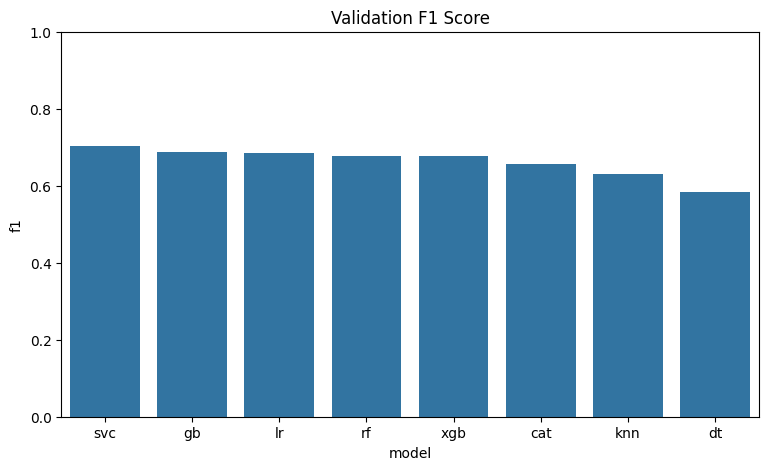

In [48]:
plt.figure(figsize=(9, 5))
sns.barplot(
    data=validation_results_df,
    x="model",
    y="f1"
)
plt.title("Validation F1 Score")
plt.ylim(0, 1)
plt.show()

**11. Final Model Selection**

The models were compared using F1-score because the target variable is
imbalanced. F1-score provides a balance between precision and recall and
is therefore more informative than accuracy alone for this classification
problem.

The final model is selected based on performance on the held-out
validation set after hyperparameter tuning.

In [49]:
best_model_name = validation_results_df.iloc[0]["model"]
final_model = best_models[best_model_name]

print("Selected final model:", best_model_name)
print(
    validation_results_df[
        validation_results_df["model"] == best_model_name
    ]
)

Selected final model: svc
  model  accuracy  precision   recall        f1   roc_auc
0   svc   0.86875   0.641026  0.78125  0.704225  0.900391


Validation Report

              precision    recall  f1-score   support

           0     0.9421    0.8906    0.9157       128
           1     0.6410    0.7812    0.7042        32

    accuracy                         0.8688       160
   macro avg     0.7916    0.8359    0.8099       160
weighted avg     0.8819    0.8688    0.8734       160



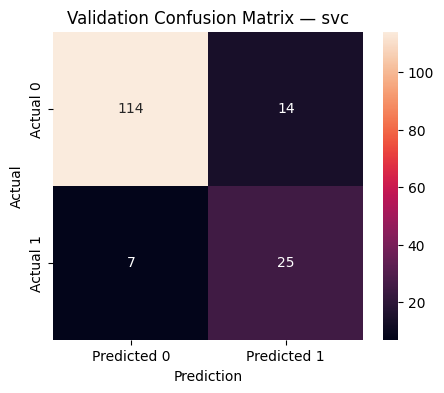

In [50]:
val_pred = final_model.predict(X_val)

print(classification_report(y_val, val_pred, digits=4))

cm = confusion_matrix(y_val, val_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Predicted 0", "Predicted 1"],
    yticklabels=["Actual 0", "Actual 1"]
)
plt.title(f"Validation Confusion Matrix — {best_model_name}")
plt.xlabel("Prediction")
plt.ylabel("Actual")
plt.show()

In [51]:
final_model.fit(X, y)

print("Final model retrained on all training data.")

Final model retrained on all training data.


**12. Prediction On Unseen Data**

In [52]:
print("Test columns:")
print(df_test.columns.tolist())

print("\nMissing values in test:")
print(df_test.isnull().sum())

print("\nTest shape:", df_test.shape)

Test columns:
['ID', 'A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score', 'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age', 'gender', 'ethnicity', 'jaundice', 'austim', 'contry_of_res', 'used_app_before', 'result', 'age_desc', 'relation']

Missing values in test:
ID                 0
A1_Score           0
A2_Score           0
A3_Score           0
A4_Score           0
A5_Score           0
A6_Score           0
A7_Score           0
A8_Score           0
A9_Score           0
A10_Score          0
age                0
gender             0
ethnicity          0
jaundice           0
austim             0
contry_of_res      0
used_app_before    0
result             0
age_desc           0
relation           0
dtype: int64

Test shape: (200, 21)


In [53]:
test_clean = df_test.copy()

DROP_COLUMNS = ["ID", "used_app_before", "age_desc"]
test_clean = test_clean.drop(columns=DROP_COLUMNS)


country_mapping = {
    "Viet Nam": "Vietnam",
    "AmericanSamoa": "Samoa"
}
test_clean["contry_of_res"] = test_clean["contry_of_res"].replace(
    country_mapping
)

ethnicity_mapping = {
    "?": "Others",
    "others": "Others"
}
test_clean["ethnicity"] = test_clean["ethnicity"].replace(
    ethnicity_mapping
)

test_clean["age"] = test_clean["age"].astype(int)
display(test_clean.head())

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jaundice,austim,contry_of_res,result,relation
0,1,1,0,0,1,1,0,0,1,1,15,m,White-European,yes,no,India,12.399055,Self
1,1,0,0,0,0,0,0,1,0,0,27,m,Asian,no,no,Mexico,6.551598,Self
2,1,1,1,0,1,1,0,1,1,1,31,m,White-European,yes,no,Egypt,3.180663,Self
3,0,0,0,0,0,0,0,0,0,0,25,m,Others,no,no,India,2.220766,Self
4,0,0,0,1,0,0,0,0,0,0,9,m,Others,no,no,Italy,7.252028,Self


In [54]:
test_predictions = final_model.predict(test_clean)

print("Number of predictions:", len(test_predictions))
print("Predicted class distribution:")
print(pd.Series(test_predictions).value_counts())

Number of predictions: 200
Predicted class distribution:
0    145
1     55
Name: count, dtype: int64


**13. Export Predictions**

In [55]:
submission = pd.DataFrame({
    "ID": df_test["ID"],
    "Class/ASD": test_predictions
})

submission_path = "test_predictions.csv"
submission.to_csv(submission_path, index=False)

display(submission.head())
print(f"Saved predictions to: {submission_path}")

,ID,Class/ASD
0,1,0
1,2,0
2,3,0
3,4,0
4,5,0


Saved predictions to: test_predictions.csv


**14. Save Trained Model**

In [56]:
model_path = "final_model.pkl"

with open(model_path, "wb") as f:
    pickle.dump(final_model, f)

print(f"Saved final model pipeline to: {model_path}")

Saved final model pipeline to: final_model.pkl


In [58]:
import joblib

joblib.dump(
    final_model,
    "final_model.pkl"
)

['final_model.pkl']